# Redes Convolucionales con PyTorch

Usaremos CIFAR-10. https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Load data

In [3]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
batch_size = 32

# Me basé en https://www.geeksforgeeks.org/python/how-to-load-cifar10-dataset-in-pytorch/
# Nota: TV = TorchVision
train_as_seen_in_tv = torchvision.datasets.CIFAR10(root='./datasets/cifar10', train=True, download=True, transform=torchvision.transforms.ToTensor())
test_as_seen_in_tv = torchvision.datasets.CIFAR10(root='./datasets/cifar10', train=False, download=True, transform=torchvision.transforms.ToTensor())

train_loader_from_tv_at_ONLY_32_batch = DataLoader(train_as_seen_in_tv, batch_size=batch_size, shuffle=True)
test_loader_from_tv_at_ONLY_32_batch = DataLoader(test_as_seen_in_tv, batch_size=batch_size, shuffle=False)

/home/david/computational-intelligence/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Preparing dataset

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [4]:
def get_batch_accuracy(output, y):
    pred = output.argmax(dim=1)
    return (pred == y).sum().item() # no me haga mucho caso pero creo que esta función estaba mal porque N es el tamaño del dataset completo y esto es un batch, incluso acertando las 32 [sic] instancias nos daría un número irremediablemente menor a 100%

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [5]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        total_correctas = 0
        total_muestras = 0
        
        test_loss = 0.0
        test_total_correctas = 0
        test_total_muestras = 0
        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            total_correctas += get_batch_accuracy(outputs, y_batch)
            total_muestras += y_batch.size(0)

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = total_correctas / total_muestras
        
        _model.eval()

        with torch.no_grad():
            for x, y in _test_loader:
                x = x.to(device)
                y = y.to(device)

                output = _model(x)
                loss = _criterion(output, y)

                test_loss += loss.item() * x.size(0)
                test_total_correctas += get_batch_accuracy(output, y)
                test_total_muestras += y.size(0)

        epoch_test_loss = test_loss / len(_test_loader.dataset)
        epoch_test_acc = test_total_correctas / test_total_muestras

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}"
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(epoch_test_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [6]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_total_correctas = 0
    test_total_muestras = 0
    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device)
            y = y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_total_correctas += get_batch_accuracy(output, y)
            test_total_muestras += y.size(0)

    return (test_loss / len(_test_loader.dataset)), (test_total_correctas / test_total_muestras)

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [7]:
model_cnn = {
    1: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 64, 3, stride=2, padding=1),
        # x: ¿por qué 64 filtros?
        # homero: para más poder
        nn.BatchNorm2d(64), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Dropout(.2),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(1024, 256),
        nn.Dropout(.3),
        nn.ReLU(),
        nn.Linear(256, 10)
    ),
    2: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 12, 3, stride=2, padding=1),
        # x: ¿por qué 12 filtros?
        # homero: para más poder
        nn.BatchNorm2d(12), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(12, 12, 3, padding=1),
        nn.BatchNorm2d(12),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(12, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Conv2d(24, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Dropout(.2),
        nn.MaxPool2d(2),

        nn.Conv2d(24, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.Conv2d(48, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(192, 96),
        nn.Dropout(.3),
        nn.ReLU(),
        nn.Linear(96, 10)
    ),
    3: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 12, 3, padding=1),
        # x: ¿por qué 12 filtros?
        # homero: para más poder
        nn.BatchNorm2d(12), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(12, 12, 3, padding=1),
        nn.BatchNorm2d(12),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(12, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Conv2d(24, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(24, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.Conv2d(48, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(768, 10)
    ),
}

for k in model_cnn.keys():
    model_cnn[k] = model_cnn[k].to(device)

In [8]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
cnn_res = {
    1: None,
    2: None,
    3: None
}
for k in model_cnn.keys():
    optimizer = Adam(model_cnn[k].parameters()) # son los mismos de todas fromas
    cnn_res[k] = train(model_cnn[k], train_loader_from_tv_at_ONLY_32_batch, test_loader_from_tv_at_ONLY_32_batch, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:04<00:00,  6.20s/epoch, test_acc=0.7724, test_loss=0.8622, train_acc=0.9258, train_loss=0.2066]


In [9]:
cnn_test_loss = {
    1: None,
    2: None,
    3: None
}
cnn_test_acc = {
    1: None,
    2: None,
    3: None
}
for k in model_cnn.keys():
    cnn_test_loss[k], cnn_test_acc[k] = test(model_cnn[k], test_loader_from_tv_at_ONLY_32_batch, loss_function)

In [10]:
comparison_dict = {
    'Modelo': [f'CNN {k}' for k in model_cnn.keys()],
    'Pérdida de prueba': [cnn_test_loss[k] for k in model_cnn.keys()],
    'Exactitud de prueba': [cnn_test_acc[k] for k in model_cnn.keys()]
}

pd.DataFrame(comparison_dict)

,Modelo,Pérdida de prueba,Exactitud de prueba
0,CNN 1,0.805057,0.8143
1,CNN 2,0.777978,0.7328
2,CNN 3,0.862205,0.7724


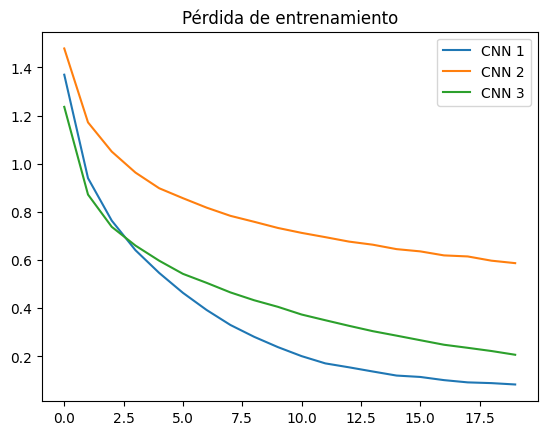

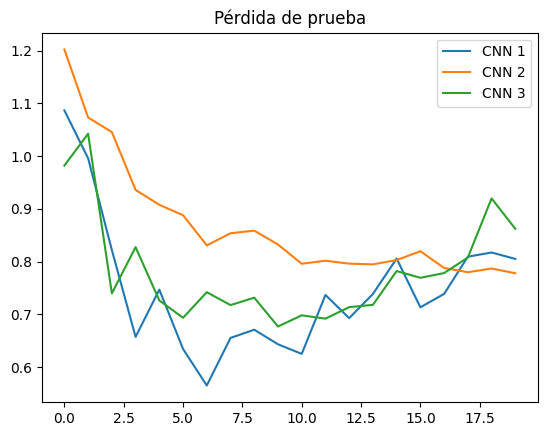

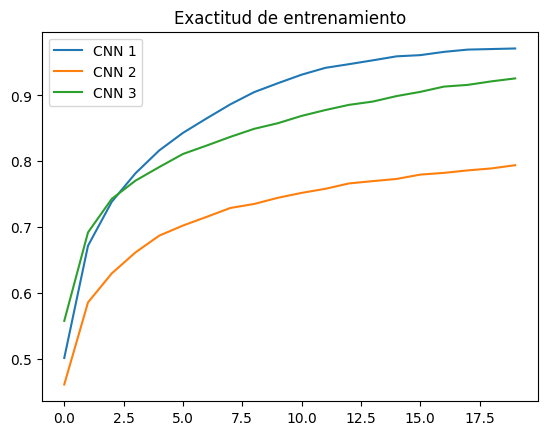

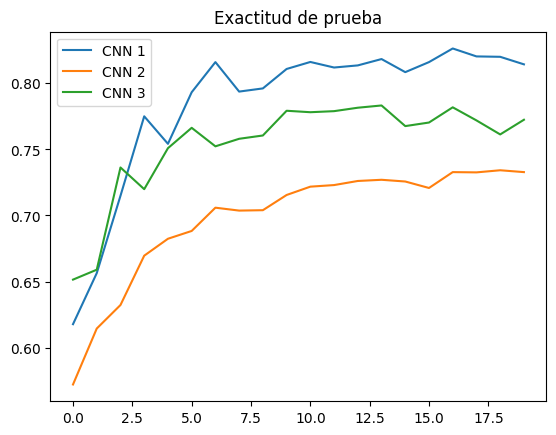

In [11]:
epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('train_loss'), label=f"CNN {k}")
plt.legend()
plt.title("Pérdida de entrenamiento")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('test_loss'), label=f"CNN {k}")
plt.legend()
plt.title("Pérdida de prueba")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('train_acc'), label=f"CNN {k}")
plt.legend()
plt.title("Exactitud de entrenamiento")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('test_acc'), label=f"CNN {k}")
plt.legend()
plt.title("Exactitud de prueba")
plt.show()